# Customer Segmentation

## Objective

The objective of this notebook is to segment customers based on their purchasing behavior using RFM (Recency, Frequency, Monetary) Analysis and K-Means Clustering. These techniques help businesses identify valuable customers and design targeted marketing strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/feature_engineered_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Shipping Duration,Profit Margin,Sales Per Unit,Discount Category,Order Value Category,Order Day,Weekend Order,Season,Customer Lifetime Sales,Customer Lifetime Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,3,16.00,130.9800,No Discount,High Value,Tuesday,False,Autumn,1148.7800,169.9344
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,3,30.00,243.9800,No Discount,High Value,Tuesday,False,Autumn,1148.7800,169.9344
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,4,47.00,7.3100,No Discount,Low Value,Sunday,True,Summer,1119.4830,-427.1840
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,7,-40.00,191.5155,Medium,High Value,Sunday,True,Autumn,2602.5755,-81.0858
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,7,11.25,11.1840,Low,Low Value,Sunday,True,Autumn,2602.5755,-81.0858


# Dataset Overview

Load the feature-engineered dataset and verify its structure before performing customer segmentation.

In [2]:
print(df.shape)

df.info()

(9994, 35)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Row ID                    9994 non-null   int64  
 1   Order ID                  9994 non-null   str    
 2   Order Date                9994 non-null   str    
 3   Ship Date                 9994 non-null   str    
 4   Ship Mode                 9994 non-null   str    
 5   Customer ID               9994 non-null   str    
 6   Customer Name             9994 non-null   str    
 7   Segment                   9994 non-null   str    
 8   Country                   9994 non-null   str    
 9   City                      9994 non-null   str    
 10  State                     9994 non-null   str    
 11  Postal Code               9994 non-null   int64  
 12  Region                    9994 non-null   str    
 13  Product ID                9994 non-null   str    
 14  Category

# RFM Analysis

RFM stands for:

- Recency
- Frequency
- Monetary Value

These three metrics are widely used to evaluate customer value.

In [3]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

reference_date = df["Order Date"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2017-12-31 00:00:00')

# Calculate RFM Metrics

In [4]:
rfm = (
    df.groupby("Customer ID")
      .agg({
          "Order Date": lambda x: (reference_date - x.max()).days,
          "Order ID": "nunique",
          "Sales": "sum"
      })
)

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.560
AA-10375,20,9,1056.390
AA-10480,260,4,1790.512
AA-10645,56,6,5086.935
AB-10015,416,3,886.156


## Business Insight

- Lower Recency indicates recently active customers.
- Higher Frequency indicates loyal customers.
- Higher Monetary value indicates valuable customers.

In [5]:
rfm.describe()

,Recency,Frequency,Monetary
count,793.000000,793.000000,793.000000
mean,147.802018,6.316520,2896.848500
std,186.211051,2.550885,2628.670117
min,1.000000,1.000000,4.833000
25%,31.000000,5.000000,1146.050000
50%,76.000000,6.000000,2256.394000
75%,184.000000,8.000000,3785.276000
max,1166.000000,17.000000,25043.050000


# Data Standardization

Scale the RFM values before applying K-Means clustering.

In [6]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled

array([[ 0.19988856, -0.51642886,  1.01511197],
       [-0.68676201,  1.05264427, -0.70059002],
       [ 0.60291154, -0.90869715, -0.4211387 ],
       ...,
       [-0.74049841,  0.66037599,  1.45549211],
       [-0.49868462,  2.62171741,  1.9523543 ],
       [ 0.29661407, -0.51642886, -0.53403045]], shape=(793, 3))

# K-Means Clustering

In [7]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
AA-10315,185,5,5563.560,1
AA-10375,20,9,1056.390,0
AA-10480,260,4,1790.512,1
AA-10645,56,6,5086.935,0
AB-10015,416,3,886.156,3


## Business Insight

Customers are divided into four groups based on purchasing behavior.

In [8]:
rfm["Cluster"].value_counts()

Cluster
1    335
0    298
3     96
2     64
Name: count, dtype: int64

# Cluster Analysis

In [9]:
cluster_summary = (
    rfm.groupby("Cluster")
       .mean()
)

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,72.741611,8.516779,3322.222985
1,101.197015,4.731343,1669.688290
2,123.718750,8.296875,9479.545687
3,559.489583,3.697917,1470.228226


## Business Insight

Compare Recency, Frequency, and Monetary values across clusters to identify customer behavior.

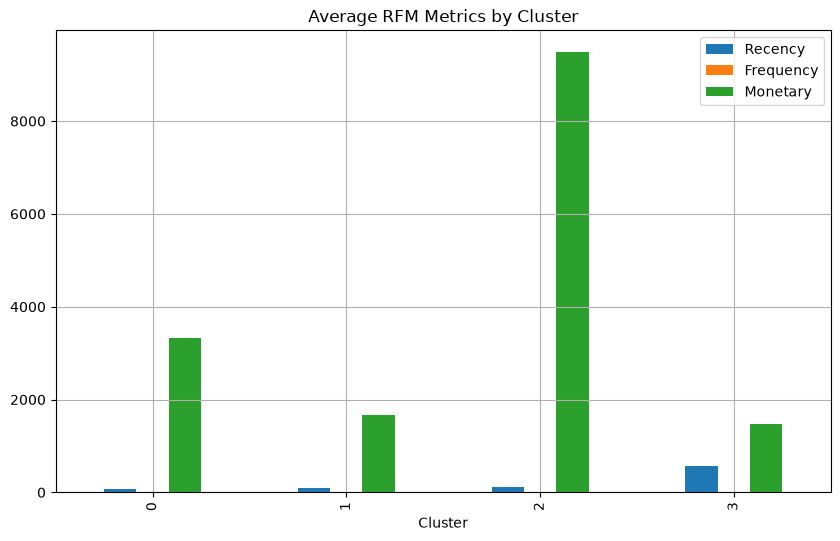

In [10]:
cluster_summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average RFM Metrics by Cluster")

plt.grid(True)

plt.show()

# Customer Distribution

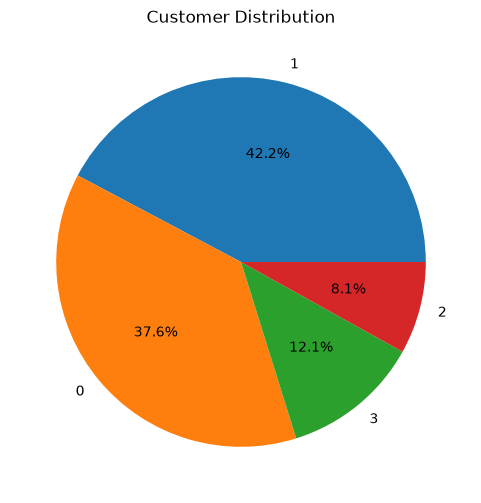

In [11]:
rfm["Cluster"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")
plt.title("Customer Distribution")

plt.show()

# Segment Naming

In [12]:
segment_names = {
    0: "Champions",
    1: "Loyal Customers",
    2: "Potential Customers",
    3: "At Risk"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
AA-10315,185,5,5563.560,1,Loyal Customers
AA-10375,20,9,1056.390,0,Champions
AA-10480,260,4,1790.512,1,Loyal Customers
AA-10645,56,6,5086.935,0,Champions
AB-10015,416,3,886.156,3,At Risk


## Business Insight

Assign meaningful business names to customer clusters to improve decision-making.

In [13]:
rfm["Segment"].value_counts()

Segment
Loyal Customers        335
Champions              298
At Risk                 96
Potential Customers     64
Name: count, dtype: int64

# Save Segmented Customers

In [14]:
rfm.to_csv(
    "../data/processed/customer_segments.csv"
)

print("Customer segmentation saved successfully!")

Customer segmentation saved successfully!


# Notebook Summary

## Tasks Completed

- Performed RFM Analysis
- Calculated Recency
- Calculated Frequency
- Calculated Monetary Value
- Standardized Data
- Applied K-Means Clustering
- Created Customer Segments
- Named Customer Groups
- Saved Segmented Dataset

## Business Recommendations

- Reward Champions with exclusive offers.
- Retain Loyal Customers through loyalty programs.
- Convert Potential Customers into regular buyers.
- Re-engage At Risk customers using personalized campaigns.